<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/MineriaDeDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# Clasificación de residuos usando minería de datos
# ============================================

# Paso 1: Importar librerías necesarias

import pandas as pd  # Sirve para trabajar con datos en forma de tablas o DataFrames
import numpy as np   # Sirve para realizar operaciones numéricas

from sklearn.preprocessing import LabelEncoder, StandardScaler
# LabelEncoder convierte datos de texto en números
# StandardScaler normaliza los datos para que tengan una escala similar

from sklearn.model_selection import train_test_split
# Permite dividir el dataset en datos de entrenamiento y datos de prueba

from sklearn.tree import DecisionTreeClassifier, plot_tree
# DecisionTreeClassifier crea el modelo de árbol de decisión
# plot_tree permite graficar el árbol de decisión

from sklearn.metrics import accuracy_score, confusion_matrix
# accuracy_score mide la precisión del modelo
# confusion_matrix muestra los aciertos y errores de clasificación

import matplotlib.pyplot as plt
# Sirve para generar gráficas

In [ ]:

# Paso 2: Crear el dataset

# En este caso se simula un conjunto de datos estructurado,
# ya que está organizado en filas y columnas.
# Cada fila representa un residuo y cada columna representa una característica.

data = {
    'peso': [0.2, 1.5, 0.3, 0.8, 2.0, 0.1, 1.2, 0.7],
    'color': ['verde', 'transparente', 'blanco', 'marrón', 'plateado', 'verde', 'azul', 'gris'],
    'textura': ['suave', 'duro', 'fibroso', 'duro', 'duro', 'suave', 'duro', 'duro'],
    'biodegradable': ['sí', 'no', 'sí', 'sí', 'no', 'sí', 'no', 'no'],
    'tipo': ['orgánico', 'vidrio', 'papel', 'orgánico', 'metal', 'orgánico', 'plástico', 'metal']
}

# Convertimos el diccionario en un DataFrame
df = pd.DataFrame(data)

# Mostramos los datos originales
print("Dataset original:")
print(df)




In [ ]:
# Paso 3: Codificar variables categóricas

# Los modelos de Machine Learning no trabajan directamente con texto,
# por eso se convierten las categorías en valores numéricos.

encoders = {}

# Columnas que contienen texto
columnas_categoricas = ['color', 'textura', 'biodegradable', 'tipo']

for columna in columnas_categoricas:
    encoder = LabelEncoder()
    df[columna] = encoder.fit_transform(df[columna])
    encoders[columna] = encoder

# Mostramos el dataset ya convertido a números
print("\nDataset codificado:")
print(df)




In [ ]:
# Paso 4: Separar variables independientes y variable dependiente

# X contiene las características que ayudan a clasificar el residuo
X = df[['peso', 'color', 'textura', 'biodegradable']]

# y contiene la clase o tipo de residuo que queremos predecir
y = df['tipo']




In [ ]:
# Paso 5: Normalizar los datos

# La normalización ayuda a que los valores estén en una escala similar.
# Esto es parte de la preparación de datos antes de aplicar minería de datos.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




In [ ]:
# Paso 6: Dividir los datos en entrenamiento y prueba

# Se usa el 70% de los datos para entrenar el modelo
# y el 30% para probar qué tan bien clasifica.

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)




In [ ]:
# Paso 7: Crear y entrenar el modelo

# Se usa un árbol de decisión porque es útil para problemas de clasificación.
# El modelo aprenderá reglas a partir de los datos de entrenamiento.

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train, y_train)

In [ ]:
# Paso 8: Evaluar el modelo

# El modelo realiza predicciones con los datos de prueba.
y_pred = modelo.predict(X_test)

# Calculamos la precisión del modelo
precision = accuracy_score(y_test, y_pred)

# Mostramos la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

print("\nPrecisión del modelo:", precision)
print("\nMatriz de confusión:")
print(matriz)

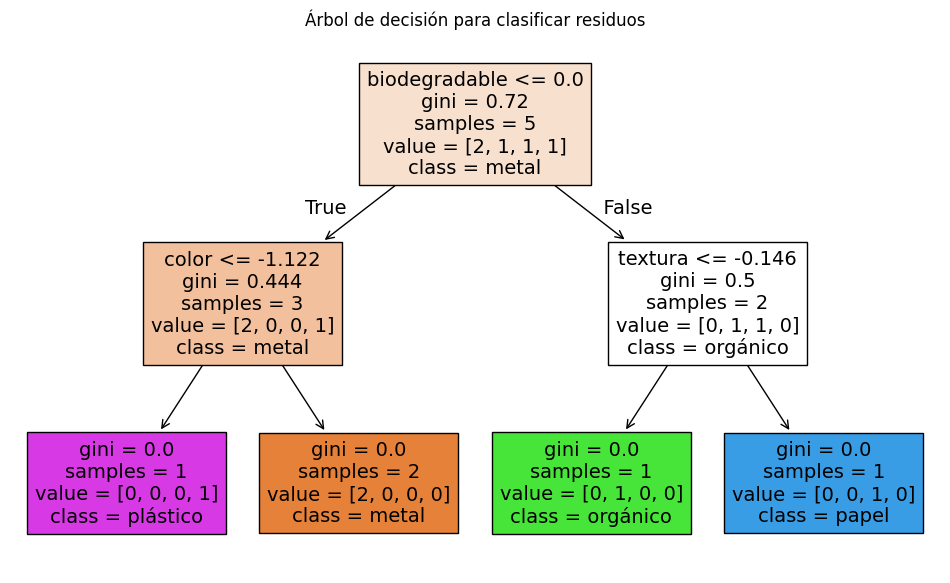

In [ ]:
# Paso 9: Graficar el árbol de decisión

# Obtenemos los nombres reales de las clases
nombres_clases = encoders['tipo'].classes_

plt.figure(figsize=(12, 7))

plot_tree(
    modelo,
    filled=True,
    feature_names=['peso', 'color', 'textura', 'biodegradable'],
    class_names=nombres_clases
)

plt.title("Árbol de decisión para clasificar residuos")
plt.show()

In [ ]:
# Paso 10: Probar el modelo con un nuevo residuo

# Ejemplo: un residuo con peso 0.5, color verde, textura suave y biodegradable
nuevo_residuo = pd.DataFrame({
    'peso': [0.5],
    'color': ['verde'],
    'textura': ['suave'],
    'biodegradable': ['sí']
})

# Codificamos el nuevo residuo usando los mismos encoders
nuevo_residuo['color'] = encoders['color'].transform(nuevo_residuo['color'])
nuevo_residuo['textura'] = encoders['textura'].transform(nuevo_residuo['textura'])
nuevo_residuo['biodegradable'] = encoders['biodegradable'].transform(nuevo_residuo['biodegradable'])

# Normalizamos el nuevo dato
nuevo_residuo_scaled = scaler.transform(nuevo_residuo)

# Realizamos la predicción
prediccion = modelo.predict(nuevo_residuo_scaled)

# Convertimos el resultado numérico a texto
tipo_predicho = encoders['tipo'].inverse_transform(prediccion)

print("\nEl residuo fue clasificado como:", tipo_predicho[0])


El residuo fue clasificado como: papel
